In [1]:
import numpy as np
import pandas as pd
import gzip
import json
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer #FOR SENTIMENT ANALYSIS
from sklearn.feature_extraction.text import TfidfVectorizer #FOR TF-IDF (FINDING IMPORTANT WORDS)
from sklearn.neighbors import BallTree #FOR SPATIAL ANALYSIS (NEIGHBOR DENSITY)


In [2]:

def parse(path):
  g = gzip.open(path, 'r')
  for l in g:
    yield json.loads(l)

vermont_reviews = pd.DataFrame(parse("data/review-Vermont_10.json.gz"))
vermont_meta = pd.DataFrame(parse("data/meta-Vermont.json.gz"))

In [3]:
def parse_first_n(path, n=1000000):
    g = gzip.open('data/' + path, 'r')
    for i, l in enumerate(g):
        if i >= n:
            break
        yield json.loads(l)

washington_reviews = pd.DataFrame(parse_first_n("review-Washington_10.json.gz"))
washington_meta = pd.DataFrame(parse_first_n("meta-Washington.json.gz"))

# What makes a brand big?
* Proportion of reviews
* Number of locations

### Vermont (Small State, Northeast) Big Brands by Proportion

In [4]:
vermont_merged_reviews = vermont_meta.merge(vermont_reviews, on='gmap_id')
vermont_merged_reviews_count = vermont_merged_reviews.groupby(by='name_x').count()
def divide_by_total_reviews(review_count):
    total_reviews = vermont_reviews.shape[0]
    return review_count / total_reviews
vermont_proportions = vermont_merged_reviews_count.get('address').apply(divide_by_total_reviews)
vermont_merged_reviews_count = vermont_merged_reviews_count.assign(proportions = vermont_proportions)
vermont_merged_reviews_count
vermont_big_brands_all = vermont_merged_reviews_count[vermont_merged_reviews_count.get('proportions') >= 0.001].sort_values(by='proportions', ascending=False)
vermont_big_brands_all

,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,...,relative_results,url,user_id,name_y,time,rating,text,pics,resp,proportions
name_x,,,,,,,,,,,,,,,,,,,,,
McDonald's,7714,7714,7714,7714,7714,7714,7714,7714,7714,7651,...,7714,7714,7714,7714,7714,7714,3724,70,0,0.023755
Dunkin',4508,4508,4508,4508,4508,4508,4508,4508,4508,4508,...,4488,4508,4508,4508,4508,4508,2154,36,0,0.013883
Hannaford Supermarket,4411,4411,0,4411,4411,4411,4411,4411,4319,4411,...,4319,4411,4411,4411,4411,4411,1933,20,0,0.013584
Dollar General,3662,3662,3662,3662,3662,3662,3662,3662,3615,3662,...,3615,3662,3662,3662,3662,3662,1833,11,0,0.011277
Shaw's,3152,3152,3152,3152,3152,3152,3152,3152,3152,3152,...,3152,3152,3152,3152,3152,3152,1500,23,18,0.009707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Guilford Welcome Center,331,331,0,331,331,331,331,331,0,331,...,331,331,331,331,331,331,204,12,2,0.001019
AT&T Store,330,330,330,330,330,330,330,330,195,330,...,330,330,330,330,330,330,177,0,74,0.001016
Okemo Mountain Resort,328,328,328,328,328,328,328,328,0,0,...,328,328,328,328,328,328,169,31,0,0.001010


### Washington (Big State, Northwest) Big Brands By Proportion

In [5]:
washington_merged_reviews = washington_meta.merge(washington_reviews, on='gmap_id')
washington_merged_reviews_count = washington_merged_reviews.groupby(by='name_x').count()
def divide_by_total_reviews_w(review_count):
    total_reviews = washington_reviews.shape[0]
    return review_count / total_reviews
washington_proportions = washington_merged_reviews_count.get('address').apply(divide_by_total_reviews_w)
washington_merged_reviews_count = washington_merged_reviews_count.assign(proportions = washington_proportions)
washington_merged_reviews_count
washington_big_brands_all = washington_merged_reviews_count[washington_merged_reviews_count.get('proportions') >= 0.001].sort_values(by='proportions', ascending=False)
washington_big_brands_all

,address,gmap_id,description,latitude,longitude,category,avg_rating,num_of_reviews,price,hours,...,relative_results,url,user_id,name_y,time,rating,text,pics,resp,proportions
name_x,,,,,,,,,,,,,,,,,,,,,
McDonald's,12581,12581,12581,12581,12581,12581,12581,12581,12581,12397,...,12581,12581,12581,12581,12581,12581,6289,136,0,0.012581
Costco Wholesale,11383,11383,11368,11383,11383,11383,11383,11383,11383,11368,...,11383,11383,11383,11383,11383,11383,4525,112,0,0.011383
Walmart Supercenter,10668,10668,0,10668,10668,10668,10668,10668,10668,10668,...,10668,10668,10668,10668,10668,10668,5448,89,0,0.010668
Starbucks,7775,7775,7763,7775,7775,7775,7775,7775,7714,6994,...,7466,7775,7775,7775,7775,7775,3742,143,1,0.007775
Dick's Drive-In,6306,6306,6306,6306,6306,6306,6306,6306,6306,6306,...,6306,6306,6306,6306,6306,6306,3252,95,22,0.006306
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Wild Ginger,1043,1043,1043,1043,1043,1043,1043,1043,1043,1043,...,1043,1043,1043,1043,1043,1043,569,47,13,0.001043
Moby Dick,1021,1021,1021,1021,1021,1021,1021,1021,1021,1021,...,1021,1021,1021,1021,1021,1021,738,32,51,0.001021
Applebee's Grill + Bar,1018,1018,1018,1018,1018,1018,1018,1018,1018,1018,...,1018,1018,1018,1018,1018,1018,572,15,7,0.001018


### Non-regional big brands (big brands that appear in both states)

In [6]:
big_brands_all_both = washington_big_brands_all.merge(vermont_big_brands_all, on='name_x')
big_brands_all_both

,address_x,gmap_id_x,description_x,latitude_x,longitude_x,category_x,avg_rating_x,num_of_reviews_x,price_x,hours_x,...,relative_results_y,url_y,user_id_y,name_y_y,time_y,rating_y,text_y,pics_y,resp_y,proportions_y
name_x,,,,,,,,,,,,,,,,,,,,,
McDonald's,12581,12581,12581,12581,12581,12581,12581,12581,12581,12397,...,7714,7714,7714,7714,7714,7714,3724,70,0,0.023755
Walmart Supercenter,10668,10668,0,10668,10668,10668,10668,10668,10668,10668,...,1497,1497,1497,1497,1497,1497,736,14,0,0.004610
Starbucks,7775,7775,7763,7775,7775,7775,7775,7775,7714,6994,...,1036,1155,1155,1155,1155,1155,550,16,0,0.003557
Subway,5064,5064,5064,5064,5064,5064,5064,5064,5064,5015,...,1710,1710,1710,1710,1710,1710,841,14,0,0.005266
The Home Depot,4592,4592,4592,4592,4592,4592,4592,4592,4592,4592,...,918,918,918,918,918,918,440,11,1,0.002827
Lowe's Home Improvement,4491,4491,4491,4491,4491,4491,4491,4491,4428,4491,...,994,994,994,994,994,994,470,8,0,0.003061
Taco Bell,2775,2775,2775,2775,2775,2775,2775,2775,2775,2775,...,1055,1055,1055,1055,1055,1055,594,10,369,0.003249
IHOP,2572,2572,2572,2572,2572,2572,2572,2572,2572,2572,...,431,431,431,431,431,431,217,7,0,0.001327
Best Buy,2459,2459,2459,2459,2459,2459,2459,2459,2459,2459,...,882,882,882,882,882,882,442,5,13,0.002716


### Classification of Brands Based On Number of Locations

#### Vermont

In [7]:
vermont_locations = vermont_meta.groupby('name').count().sort_values(by='address', ascending=False)
def location_classification(num_locations):
    if num_locations == 1:
        return 'individual'
    elif num_locations < 20:
        return 'small'
    else:
        return 'chain'
vermont_locations = vermont_locations.assign(num_locations = vermont_locations.get('gmap_id'))
vermont_locations['brand_size'] = (vermont_locations['num_locations'].apply(location_classification))
vermont_locations_classification = vermont_locations.get(['brand_size'])
vermont_locations_classification
    

,brand_size
name,
Mobil,chain
Dunkin',chain
United States Postal Service,chain
Subway,chain
Irving Oil,chain
...,...
"Allen S. Hulbert Plumbing & Heating, Inc",individual
Aloha Body Therapy / Stowe Mobile Massage,individual
All The Details,individual


##### Washington

In [8]:
washington_locations = washington_meta.groupby('name').count().sort_values(by='address', ascending=False)
washington_locations = washington_locations.assign(num_locations = washington_locations.get('gmap_id'))
washington_locations['brand_size'] = (washington_locations['num_locations'].apply(location_classification))
washington_locations_classification = washington_locations.get(['brand_size'])
washington_locations_classification

,brand_size
name,
Starbucks,chain
Subway,chain
Shell,chain
76,chain
McDonald's,chain
...,...
Window Genie of Spokane,individual
Window Genie of Olympia,individual
"Window Cleaning 4 U, LLC",individual


# SENTIMENT ANALYSIS

### Comparison of Sentiment Across Regions

In [9]:
sid_obj = SentimentIntensityAnalyzer()
def vader_scores(sentence):
    return sid_obj.polarity_scores(sentence)

In [18]:
# Only get the reviews of large brands in the two states

## Vermont
vermont_large_brands_list = vermont_locations_classification[vermont_locations_classification.get('brand_size') == 'chain'].index
vermont_large_brands_ids = vermont_meta[vermont_meta.get('name').isin(vermont_large_brands_list)].set_index('gmap_id').index
vermont_large_brand_reviews = vermont_reviews[vermont_reviews.get('gmap_id').isin(vermont_large_brands_ids)]
vermont_large_brand_reviews = vermont_large_brand_reviews[~vermont_large_brand_reviews.get('text').isna()]

## Washington
washington_large_brands_list = washington_locations_classification[washington_locations_classification.get('brand_size') == 'chain'].index
washington_large_brands_ids = washington_meta[washington_meta.get('name').isin(washington_large_brands_list)].set_index('gmap_id').index
washington_large_brand_reviews = washington_reviews[washington_reviews.get('gmap_id').isin(washington_large_brands_ids)]
washington_large_brand_reviews = washington_large_brand_reviews[~washington_large_brand_reviews.get('text').isna()]


In [22]:
# Getting sentiment scores

## Vermont
vermont_scores_ = vermont_large_brand_reviews['text'].apply(vader_scores)
vermont_scores = vermont_scores_.apply(pd.Series)
vermont_large_brand_reviews = vermont_large_brand_reviews.join(vermont_scores, rsuffix="new")

## Washington
washington_scores_ = washington_large_brand_reviews['text'].apply(vader_scores)
washington_scores = washington_scores_.apply(pd.Series)
washington_large_brand_reviews = washington_large_brand_reviews.join(washington_scores, rsuffix="new")

##### Issues with sentiment analysis using VADER

###### Imperfect scoring

In [27]:
washington_large_brand_reviews

,user_id,name,time,rating,text,pics,resp,gmap_id,neg,neu,pos,compound
179,105962529295221230004,Elma Aguilar,1621262381724,5,I am always greeted with a hello and the guys ...,None,None,0x5490fc48a23c4bc3:0x9450327fb8d331f9,0.000,0.664,0.336,0.8439
180,113715462151102880246,Chris H.,1610391119195,5,Great gas station.,None,None,0x5490fc48a23c4bc3:0x9450327fb8d331f9,0.000,0.328,0.672,0.6249
181,116614099645903094567,Dennis G.C,1596002100826,1,Be careful! They will short change you!!,None,None,0x5490fc48a23c4bc3:0x9450327fb8d331f9,0.000,0.708,0.292,0.3561
182,111991567777534594168,Vision Painter,1578334070830,2,I don't like looking at graffiti while at the ...,None,None,0x5490fc48a23c4bc3:0x9450327fb8d331f9,0.093,0.789,0.118,0.1506
183,108985485219972754141,Lester D,1560371530174,4,It's convenient,None,None,0x5490fc48a23c4bc3:0x9450327fb8d331f9,0.000,1.000,0.000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
998442,116183543895997057085,howard stevens,1496760704576,1,Worst Post office I have ever been to..have co...,None,None,0x549aaa9bf8e2a0c7:0x6e0998201546ef6,0.286,0.714,0.000,-0.7783
998443,116531326283944273670,Ben Hernandez,1485728490662,2,Wait times are crazy.,None,None,0x549aaa9bf8e2a0c7:0x6e0998201546ef6,0.444,0.556,0.000,-0.3400
998444,102902211699994090746,Timothy Stafford,1467151536607,1,Post office at its worst. Nobody cares that t...,None,None,0x549aaa9bf8e2a0c7:0x6e0998201546ef6,0.204,0.647,0.149,-0.2732
998445,107989645880199047774,Maria Figueroa,1426723158992,1,Customer service is horrible,None,None,0x549aaa9bf8e2a0c7:0x6e0998201546ef6,0.538,0.462,0.000,-0.5423


In [28]:
vermont_large_brand_reviews

,user_id,name,time,rating,text,pics,resp,gmap_id,neg,neu,pos,compound
288,108758476807946989876,mooney576,1618685555898,5,This is the nicest Dollar General I have ever ...,None,None,0x4cb557211ca274a7:0xea1066df24155f3f,0.0,0.665,0.335,0.9200
289,107910713451324158864,Ramona Boswell,1618720230434,5,Found my spin mop for a very reasonable price ...,None,None,0x4cb557211ca274a7:0xea1066df24155f3f,0.0,0.853,0.147,0.5859
290,104194948209630774333,Margaret Korda,1618089231515,5,"Children activity books, toys, almond milk, wo...",None,None,0x4cb557211ca274a7:0xea1066df24155f3f,0.0,0.736,0.264,0.7269
291,115609550906928329447,Nickie Farone,1606002449608,5,My first time to this new Dollar General in Sh...,None,None,0x4cb557211ca274a7:0xea1066df24155f3f,0.0,0.786,0.214,0.9685
292,116807005411196146915,Chris Morris,1614431327231,5,"This place is new, nicely stocked, great custo...",None,None,0x4cb557211ca274a7:0xea1066df24155f3f,0.0,0.490,0.510,0.8070
...,...,...,...,...,...,...,...,...,...,...,...,...
324467,106781489838055963299,jade shanahan,1487758136211,1,It's one of the filthiest places I've ever been.,None,None,0x4cc98bab87970361:0x39b72c846d9c2de0,0.0,1.000,0.000,0.0000
324468,101345679541877039790,Victor Nikulin,1486989570596,4,"good store, good location",None,None,0x4cc98bab87970361:0x39b72c846d9c2de0,0.0,0.256,0.744,0.7003
324469,113757663893762234170,Tara Blodgett,1499312266764,5,Great store love it,None,None,0x4cc98bab87970361:0x39b72c846d9c2de0,0.0,0.194,0.806,0.8519
324470,113538754158444251861,Xtrmdream,1551286839497,4,(Translated by Google) A1\n\n(Original)\nA1,None,None,0x4cc98bab87970361:0x39b72c846d9c2de0,0.0,0.685,0.315,0.3182


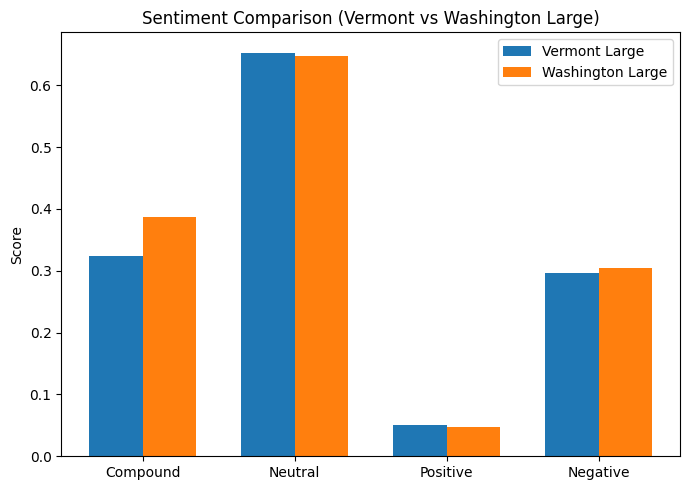

In [26]:
vermont_compound_overall = vermont_large_brand_reviews.get('compound').mean()
vermont_neutral_overall = vermont_large_brand_reviews.get('neu').mean()
vermont_positive_overall = vermont_large_brand_reviews.get('pos').mean()
vermont_negative_overall = vermont_large_brand_reviews.get('neg').mean()
vermont_all_scores = [vermont_compound_overall, vermont_neutral_overall, vermont_negative_overall, vermont_positive_overall]

washington_compound_overall = washington_large_brand_reviews.get('compound').mean()
washington_neutral_overall = washington_large_brand_reviews.get('neu').mean()
washington_positive_overall = washington_large_brand_reviews.get('pos').mean()
washington_negative_overall = washington_large_brand_reviews.get('neg').mean()
washington_all_scores = [washington_compound_overall, washington_neutral_overall, washington_negative_overall, washington_positive_overall]

#PLOT VERMONT VS WASHINGTON CHAIN
labels = ['Compound', 'Neutral', 'Positive', 'Negative']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, vermont_all_scores, width, label='Vermont Large')
plt.bar(x + width/2, washington_all_scores, width, label='Washington Large')

plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Sentiment Comparison (Vermont vs Washington Large)')
plt.legend()
plt.tight_layout()
plt.show()


###### Inconsistent Breakdown of Scores

In [36]:
vermont_independent_brands_list = vermont_locations_classification[vermont_locations_classification.get('brand_size') == 'individual'].index
vermont_independent_brands_ids = vermont_meta[vermont_meta.get('name').isin(vermont_independent_brands_list)].set_index('gmap_id').index
vermont_independent_brand_reviews = vermont_reviews[vermont_reviews.get('gmap_id').isin(vermont_independent_brands_ids)]

vermont_scores_independent_ = vermont_independent_brand_reviews['text'].dropna().apply(vader_scores)
vermont_scores_independent = vermont_scores_independent_.apply(pd.Series)
vermont_independent_brand_reviews = vermont_independent_brand_reviews.join(vermont_scores_independent, rsuffix = "new")

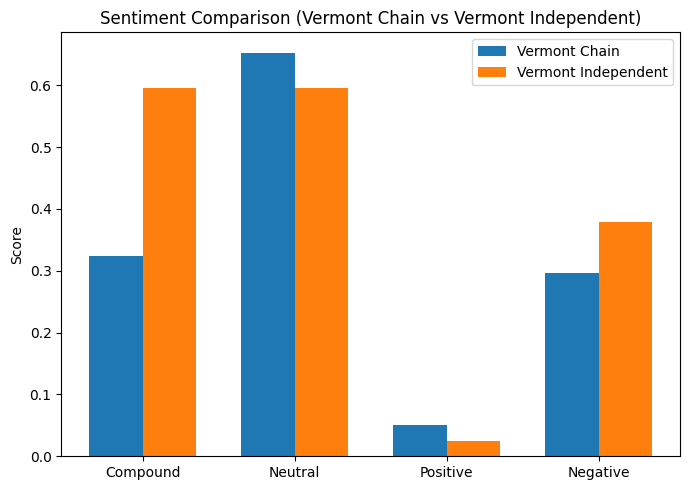

In [39]:
vermont_compound_overall_independent = vermont_independent_brand_reviews.get('compound').mean()
vermont_neutral_overall_independent = vermont_independent_brand_reviews.get('neu').mean()
vermont_positive_overall_independent = vermont_independent_brand_reviews.get('pos').mean()
vermont_negative_overall_independent = vermont_independent_brand_reviews.get('neg').mean()
vermont_all_scores_independent = [vermont_compound_overall_independent, vermont_neutral_overall_independent, vermont_negative_overall_independent, vermont_positive_overall_independent]

#PLOT 
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 5))
plt.bar(x - width/2, vermont_all_scores, width, label='Vermont Chain')
plt.bar(x + width/2, vermont_all_scores_independent, width, label='Vermont Independent')

plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Sentiment Comparison (Vermont Chain vs Vermont Independent)')
plt.legend()
plt.tight_layout()
plt.show()


# New approach: Binning 1-2 Star reviews and 4-5 star reviews to compare rural vs urban common complaints/praises

## Question: Are bad vs good reviews different in urban vs rural areas?

#### Classifying a business being "urban" as being in the top third when ranking density of neighbors, and "rural" as being in the bottom third

In [41]:
coords = vermont_merged_reviews[['latitude', 'longitude']].dropna().values
coords_rad = np.radians(coords)
df_valid = vermont_merged_reviews[['latitude','longitude']].dropna().copy()
coords_rad = np.radians(df_valid[['latitude','longitude']].values)

tree = BallTree(coords_rad, metric='haversine')
radius_miles = 5
radius = radius_miles / 3959
counts = tree.query_radius(coords_rad, r=radius, count_only=True)

In [42]:
df_valid['local_density'] = counts - 1
vermont_merged_reviews.loc[df_valid.index, 'local_density'] = df_valid['local_density']
vermont_merged_reviews['density_bin'] = pd.qcut(
    vermont_merged_reviews['local_density'],
    q=3,
    labels=['Rural','Suburban','Urban']
)
vermont_merged_reviews = vermont_merged_reviews[~vermont_merged_reviews.get('text').isna()]

#### URBAN

##### Good Reviews (4-5 Stars)

In [43]:
vermont_urban_reviews = vermont_merged_reviews[vermont_merged_reviews.get('density_bin') == 'Urban']
urban_vermont_reviews_good = vermont_urban_reviews[(vermont_urban_reviews.get('rating') == 4) | (vermont_urban_reviews.get('rating') == 5)]
list_of_urban_vermont_reviews_good = urban_vermont_reviews_good.get('text').tolist()

urban_tfidf_good = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=5, ngram_range=(2,2))

urban_result_good = urban_tfidf_good.fit_transform(list_of_urban_vermont_reviews_good)

urban_feature_names_good = urban_tfidf_good.get_feature_names_out()
mean_urban_tfidf_good = np.asarray(urban_result_good.mean(axis=0)).flatten()
top_n = 20

top_indices_good_urban = mean_urban_tfidf_good.argsort()[-top_n:][::-1]

top_words_good_urban = [(urban_feature_names_good[i], mean_urban_tfidf_good[i]) for i in top_indices_good_urban]

for word, score in top_words_good_urban:
    print(word, score)

great food 0.015071112202296934
great place 0.014908965644615855
good food 0.012451808562099152
great service 0.010937021748764864
friendly staff 0.009673747160996657
food great 0.007340405298337452
food good 0.007151980845406325
love place 0.006395387852109292
great selection 0.006168600303685033
good service 0.005645761719367424
customer service 0.005265145725585074
food service 0.005067721664070595
staff friendly 0.004389955313132616
helpful staff 0.004367715662786092
nice place 0.004262676742253694
good place 0.004213556458703637
great staff 0.004166628635710948
service great 0.004014039791890606
highly recommend 0.00364381569198785
good selection 0.003586006518311247


##### Bad Reviews (1-2 Stars)

In [44]:
urban_vermont_reviews_bad = vermont_urban_reviews[(vermont_urban_reviews.get('rating') == 1) | (vermont_urban_reviews.get('rating') == 2)]
list_of_urban_vermont_reviews_bad = urban_vermont_reviews_bad.get('text').tolist()

urban_tfidf_bad = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=5, ngram_range=(2,2))

urban_result_bad = urban_tfidf_bad.fit_transform(list_of_urban_vermont_reviews_bad)

urban_feature_names_bad = urban_tfidf_bad.get_feature_names_out()
mean_urban_tfidf_bad = np.asarray(urban_result_bad.mean(axis=0)).flatten()
top_n = 20

top_indices_bad_urban = mean_urban_tfidf_bad.argsort()[-top_n:][::-1]

top_words_bad_urban = [(urban_feature_names_bad[i], mean_urban_tfidf_bad[i]) for i in top_indices_bad_urban]

for word, score in top_words_bad_urban:
    print(word, score)

customer service 0.020689664589762884
translated google 0.005971798967931004
don know 0.005793147034059661
food good 0.005661067078520386
slow service 0.005183184260510671
parking lot 0.0045602095968255915
15 minutes 0.004556621302809385
food cold 0.004442188823199537
10 minutes 0.004362478484920803
20 minutes 0.004010936287619023
don care 0.003897055912213208
30 minutes 0.0037524742124351545
long wait 0.0037458139161990144
food great 0.0037214586647246013
feel like 0.003614345613770357
rude staff 0.0035877930785709524
poor service 0.003532216684230897
long time 0.0034110858479864366
fast food 0.003294356108501887
waste time 0.0032828593263602543


#### RURAL

##### Good Reviews (4-5 Stars)

In [45]:
vermont_rural_reviews = vermont_merged_reviews[vermont_merged_reviews.get('density_bin') == 'Rural']
rural_vermont_reviews_good = vermont_rural_reviews[(vermont_rural_reviews.get('rating') == 4) | (vermont_rural_reviews.get('rating') == 5)]
list_of_rural_vermont_reviews_good = rural_vermont_reviews_good.get('text').tolist()

rural_tfidf_good = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=5, ngram_range=(2,2))

rural_result_good = rural_tfidf_good.fit_transform(list_of_rural_vermont_reviews_good)

rural_feature_names_good = rural_tfidf_good.get_feature_names_out()
mean_rural_tfidf_good = np.asarray(rural_result_good.mean(axis=0)).flatten()
top_n = 20

top_indices_good_rural = mean_rural_tfidf_good.argsort()[-top_n:][::-1]

top_words_good_rural = [(rural_feature_names_good[i], mean_rural_tfidf_good[i]) for i in top_indices_good_rural]

for word, score in top_words_good_rural:
    print(word, score)

great food 0.01998226129182115
great place 0.0168244858308809
good food 0.014652813193041722
great service 0.009890156664051209
friendly staff 0.009812462459312965
food great 0.008784716726914669
food good 0.006507823159512514
nice place 0.005830944182487618
love place 0.005676976329284763
food service 0.005505519411565386
ice cream 0.00534136141644139
good service 0.004915191527017349
good place 0.0045705342734525456
great staff 0.004403917884474887
great selection 0.004369947073033031
friendly service 0.004117875030731592
great people 0.003881422480380917
staff friendly 0.003791584791353189
service great 0.00357086184590368
customer service 0.0035380658570658926


##### Bad Reviews (1-2 Stars)

In [46]:
rural_vermont_reviews_bad = vermont_rural_reviews[(vermont_rural_reviews.get('rating') == 1) | (vermont_rural_reviews.get('rating') == 2)]
list_of_rural_vermont_reviews_bad = rural_vermont_reviews_bad.get('text').tolist()

rural_tfidf_bad = TfidfVectorizer(stop_words='english', max_df=0.8, min_df=5, ngram_range=(2,2))

rural_result_bad = rural_tfidf_bad.fit_transform(list_of_rural_vermont_reviews_bad)

rural_feature_names_bad = rural_tfidf_bad.get_feature_names_out()
mean_rural_tfidf_bad = np.asarray(rural_result_bad.mean(axis=0)).flatten()
top_n = 20

top_indices_bad_rural = mean_rural_tfidf_bad.argsort()[-top_n:][::-1]

top_words_bad_rural = [(rural_feature_names_bad[i], mean_rural_tfidf_bad[i]) for i in top_indices_bad_rural]

for word, score in top_words_bad_rural:
    print(word, score)

customer service 0.01628910523216944
food good 0.008141743386588823
ice cream 0.007705656270342022
poor service 0.0075233220278810575
slow service 0.007227000506744814
translated google 0.00593918155750336
prices high 0.005507729740401133
grocery store 0.005462793747195944
don know 0.005433004803982775
food ok 0.00537733410032548
long wait 0.005376540041190762
good place 0.004947758624723825
staff friendly 0.004742757128097003
20 minutes 0.004488179075325606
fast food 0.004479178929293807
15 minutes 0.00438360406019625
food service 0.004286573275645701
food cold 0.004243696822132836
high prices 0.004121345248801607
45 minutes 0.004023925322398056
